# Unidad 2: Aprendizaje Automático
## Clustering con K-Means — Aprendizaje No Supervisado
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

<!-- <img src="https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/notebooks/ml/images/pexels-ja-kubislav-374578277-14534753.jpg" alt="Clustering" width="700"/>

*Foto de [Ja Kubislav](https://www.pexels.com/@ja-kubislav-374578277/) en [Pexels](https://www.pexels.com/)* -->

--

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/unsupervised/02_Clustering_KMeans.ipynb)


## 🎯 Objetivos de Aprendizaje

Al finalizar este notebook vas a poder:

✅ Explicar qué es el clustering y para qué sirve  
✅ Implementar K-Means con `sklearn` paso a paso  
✅ Visualizar grupos reales vs clusters generados  
✅ Elegir el número óptimo de clusters con el **método del codo** y el **índice de silueta**  
✅ Interpretar las matrices de confusión entre grupos reales y clusters  

---

## 📖 Marco Teórico

### ¿Qué es el Clustering?

El clustering es una técnica de **aprendizaje no supervisado** que agrupa observaciones sin conocer sus etiquetas. El objetivo es que los puntos dentro de un mismo grupo sean **similares entre sí** y **distintos** de los de otros grupos.

> 📌 A diferencia de la clasificación, en clustering **no existe una variable respuesta (y)**. El algoritmo descubre la estructura interna de los datos.

---

### K-Means

K-Means es el algoritmo de clustering más utilizado. Divide los datos en $k$ clusters asignando cada punto al centroide más cercano.

**Algoritmo (iterativo):**

1. Inicializar $k$ centroides aleatoriamente
2. **Asignación**: cada punto se asigna al centroide más cercano (distancia Euclidea):
$$c^{(i)} = \arg\min_j \|x^{(i)} - \mu_j\|^2$$
3. **Actualización**: recalcular cada centroide como la media de sus puntos asignados:
$$\mu_j = \frac{1}{|C_j|} \sum_{i \in C_j} x^{(i)}$$
4. Repetir hasta convergencia (centroides estables)

**Función de costo (inercia / varianza intra-cluster):**
$$J = \sum_{j=1}^{k} \sum_{i \in C_j} \|x^{(i)} - \mu_j\|^2$$

K-Means **minimiza** $J$. A mayor $k$, menor inercia — pero más complejo el modelo.

---

### ¿Cómo elegir k?

#### 🔧 Método del codo (Elbow)

Graficar la inercia en función de $k$. El punto donde la curva "hace codo" (deja de bajar bruscamente) sugiere el $k$ óptimo.

#### 📐 Índice de Silueta (Silhouette)

Para cada punto $i$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}$$

donde:
- $a(i)$ = distancia media a los puntos del **mismo cluster** (cohesión)
- $b(i)$ = distancia media al cluster **más cercano** (separación)

$s(i) \in [-1, 1]$: valores cercanos a **1** → bien asignado, cercanos a **0** → en el borde, negativos → posiblemente mal asignado.

El **índice medio de silueta** se maximiza en el $k$ óptimo.

---

### Propiedades y limitaciones de K-Means

| Propiedad | Detalle |
|---|---|
| Complejidad | $O(n \cdot k \cdot i \cdot d)$ — $n$ puntos, $k$ clusters, $i$ iteraciones, $d$ dimensiones |
| Sensibilidad a escala | ✅ Sí — siempre escalar antes |
| Sensibilidad a outliers | ✅ Sí — los centroides se distorsionan |
| Forma de clusters esperada | Esférica / convexa |
| Clusters de distinto tamaño | ⚠️ Dificultad con clusters muy desiguales |
| Determinismo | ❌ Depende de la inicialización — usar `random_state` |

> 📚 Referencia principal: [Clustering con Python — cienciadedatos.net](https://www.cienciadedatos.net/documentos/py20-clustering-con-python.html)


## ⚙️ Paso 1: Importar las Librerías


In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from matplotlib import style

from sklearn.datasets import make_blobs
from sklearn.preprocessing import scale
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
style.use('ggplot')
warnings.filterwarnings('ignore')

SEED = 42
print('✅ Librerías importadas correctamente')


✅ Librerías importadas correctamente


## 🗄️ Paso 2: Datos Simulados con `make_blobs`

Generamos un dataset sintético de 300 puntos en 2D con **4 centros** usando `make_blobs`. Al tener 2 features, podemos representar los datos directamente en un plano cartesiano.

> 💡 `make_blobs` es ideal para entender algoritmos de clustering: sabemos cuántos grupos hay y podemos comparar los clusters generados con la verdad de fondo.


In [2]:
# Simulación de datos con make_blobs
X, y = make_blobs(
    n_samples=300,
    n_features=2,
    centers=4,
    cluster_std=0.99,
    shuffle=True,
    random_state=0
)

print(f'📊 Dataset generado: {X.shape[0]} muestras, {X.shape[1]} features')
print(f'   Grupos reales (y): {np.unique(y)} — {len(np.unique(y))} clases')
print()
print('Primeras 10 filas de X:')
df_preview = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
df_preview['Grupo real'] = y
print(df_preview.head(10).to_string(index=False))
print()
print('Distribución de grupos:')
for grupo in np.unique(y):
    print(f'  Grupo {grupo}: {np.sum(y == grupo)} muestras')


📊 Dataset generado: 300 muestras, 2 features
   Grupos reales (y): [0 1 2 3] — 4 clases

Primeras 10 filas de X:
 Feature 1  Feature 2  Grupo real
  0.044890   2.941512           1
 -1.521170   7.132829           3
  1.271526   5.616909           0
 -0.869351   7.801560           3
  0.761806   2.539213           1
  4.336145  -0.151752           1
 -1.991080   0.738455           2
  1.698070   4.431480           0
  0.473228   8.819910           3
 -0.361948   9.196674           3

Distribución de grupos:
  Grupo 0: 75 muestras
  Grupo 1: 75 muestras
  Grupo 2: 75 muestras
  Grupo 3: 75 muestras


## 📏 Paso 3: Escalado de Datos y Visualización

Antes de aplicar K-Means es **obligatorio escalar** los datos. K-Means usa distancias euclídeas: si una feature tiene valores en miles y otra en decimales, la primera va a dominar los cálculos.

Visualizamos los datos originales (sin color) y los escalados (coloreados por grupo real).


Estadísticas ANTES del escalado:
  Media:    [-0.05  3.95]
  Std:      [1.82 2.7 ]

Estadísticas DESPUÉS del escalado:
  Media:    [-0.  0.]  (≈ 0)
  Std:      [1. 1.]  (≈ 1)


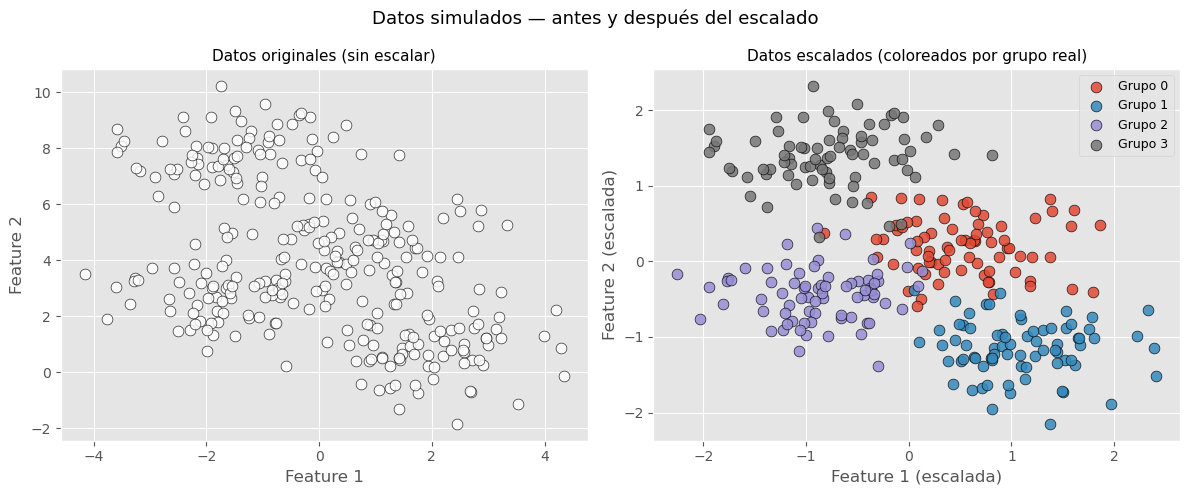

💡 En el panel izquierdo no sabemos los grupos. En el derecho los vemos coloreados.
   ⚠️ En clustering REAL no tenemos los colores — el algoritmo los tiene que encontrar.


In [3]:
# Escalado de datos
X_scaled = preprocessing.scale(X)

print('Estadísticas ANTES del escalado:')
print(f'  Media:    {X.mean(axis=0).round(2)}')
print(f'  Std:      {X.std(axis=0).round(2)}')
print()
print('Estadísticas DESPUÉS del escalado:')
print(f'  Media:    {X_scaled.mean(axis=0).round(6)}  (≈ 0)')
print(f'  Std:      {X_scaled.std(axis=0).round(6)}  (≈ 1)')

# Paleta de colores del estilo ggplot
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Datos simulados — antes y después del escalado', fontsize=13)

# Panel izquierdo: datos SIN escalar, sin colorear (como en el script original)
ax[0].scatter(x=X[:, 0], y=X[:, 1], c='white', marker='o',
              edgecolor='black', s=60, alpha=0.8)
ax[0].set_title('Datos originales (sin escalar)', fontsize=11)
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Feature 2')

# Panel derecho: datos ESCALADOS, coloreados por grupo real
for i in np.unique(y):
    ax[1].scatter(
        x=X_scaled[y == i, 0],
        y=X_scaled[y == i, 1],
        c=colors[i],
        marker='o',
        edgecolor='black',
        s=60,
        alpha=0.85,
        label=f'Grupo {i}'
    )
ax[1].set_title('Datos escalados (coloreados por grupo real)', fontsize=11)
ax[1].set_xlabel('Feature 1 (escalada)')
ax[1].set_ylabel('Feature 2 (escalada)')
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print('💡 En el panel izquierdo no sabemos los grupos. En el derecho los vemos coloreados.')
print('   ⚠️ En clustering REAL no tenemos los colores — el algoritmo los tiene que encontrar.')


## 🤖 Paso 4: Modelo K-Means Básico

Entrenamos K-Means con `k=4` (que coincide con los grupos reales) y comparamos los **grupos reales** con los **clusters generados** por el algoritmo.

> ⚠️ Los colores/números de los clusters K-Means **no necesariamente coinciden** con los grupos reales — son asignaciones arbitrarias. Lo importante es que los puntos estén bien agrupados.


In [4]:
# Dataset para esta sección (cluster_std=1 como en 02Modelo.py)
X2, y2 = make_blobs(n_samples=300, n_features=2, centers=4, cluster_std=1,
                    shuffle=True, random_state=10)
X2_scaled = scale(X2)

# Entrenar K-Means con k=4
modelo_kmeans = KMeans(n_clusters=4, n_init=25, random_state=123)
modelo_kmeans.fit(X=X2_scaled)
y_predict = modelo_kmeans.predict(X=X2_scaled)

print('📊 K-Means entrenado con k=4')
print(f'   Inercia (varianza intra-cluster): {modelo_kmeans.inertia_:.2f}')
print(f'   Iteraciones hasta convergencia:   {modelo_kmeans.n_iter_}')
print()
print('Distribución de clusters generados:')
for c in np.unique(y_predict):
    print(f'  Cluster {c}: {np.sum(y_predict == c)} muestras')


📊 K-Means entrenado con k=4
   Inercia (varianza intra-cluster): 20.29
   Iteraciones hasta convergencia:   2

Distribución de clusters generados:
  Cluster 0: 75 muestras
  Cluster 1: 75 muestras
  Cluster 2: 75 muestras
  Cluster 3: 75 muestras


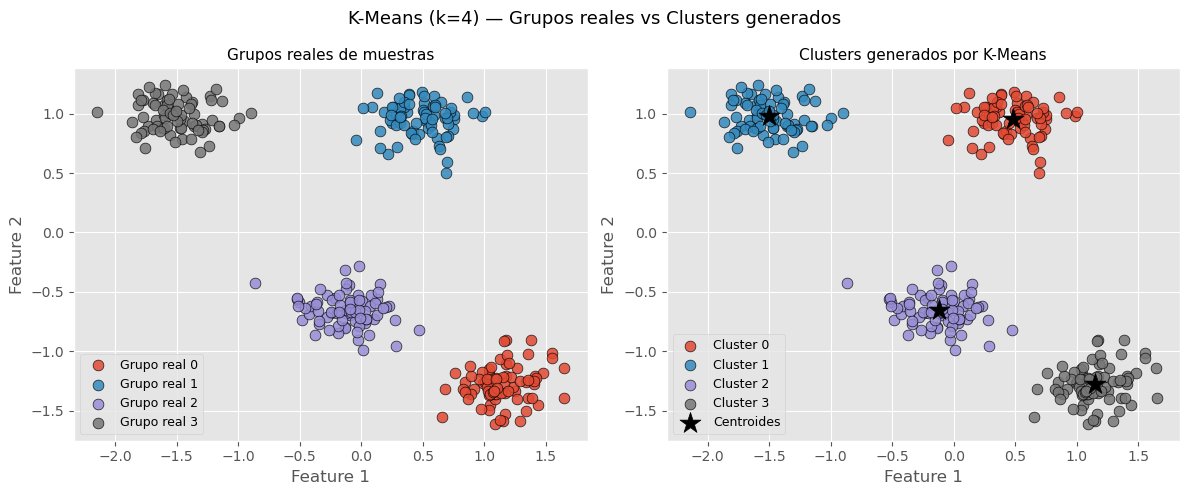

💡 Los centroides (★) están en el centro de masa de cada cluster.
   Los colores de clusters y grupos reales pueden no coincidir — es normal.


In [5]:
# Visualización: grupos reales vs clusters generados
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('K-Means (k=4) — Grupos reales vs Clusters generados', fontsize=13)

# Panel izquierdo: grupos reales
for i in np.unique(y2):
    ax[0].scatter(
        x=X2_scaled[y2 == i, 0],
        y=X2_scaled[y2 == i, 1],
        c=colors[i],
        marker='o',
        edgecolor='black',
        s=60,
        alpha=0.85,
        label=f'Grupo real {i}'
    )
ax[0].set_title('Grupos reales de muestras', fontsize=11)
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Feature 2')
ax[0].legend(fontsize=9)

# Panel derecho: clusters K-Means
for i in np.unique(y_predict):
    ax[1].scatter(
        x=X2_scaled[y_predict == i, 0],
        y=X2_scaled[y_predict == i, 1],
        c=colors[i],
        marker='o',
        edgecolor='black',
        s=60,
        alpha=0.85,
        label=f'Cluster {i}'
    )

ax[1].scatter(
    x=modelo_kmeans.cluster_centers_[:, 0],
    y=modelo_kmeans.cluster_centers_[:, 1],
    c='black',
    s=250,
    marker='*',
    zorder=5,
    label='Centroides'
)
ax[1].set_title('Clusters generados por K-Means', fontsize=11)
ax[1].set_xlabel('Feature 1')
ax[1].set_ylabel('Feature 2')
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print('💡 Los centroides (★) están en el centro de masa de cada cluster.')
print('   Los colores de clusters y grupos reales pueden no coincidir — es normal.')


## 🔢 Paso 5: ¿Qué pasa si elegimos k equivocado?

En la práctica **no sabemos cuántos clusters hay**. Comparamos k=2, k=4 y k=6 sobre el mismo dataset para ver visualmente el impacto. También usamos **matrices de confusión** (crosstab) para ver la correspondencia entre grupos reales y clusters.


In [6]:
# Dataset con clusters bien definidos (cluster_std=0.60 como en 03n-ClustersComparativa.py)
X3, y3 = make_blobs(n_samples=300, n_features=2, centers=4, cluster_std=0.60,
                    shuffle=True, random_state=0)
X3_scaled = scale(X3)

# Tres modelos con diferente k
modelos_k = {}
for k in [2, 4, 6]:
    m = KMeans(n_clusters=k, n_init=25, random_state=123)
    m.fit(X=X3_scaled)
    modelos_k[k] = (m, m.predict(X=X3_scaled))

# Matrices de confusión (crosstab grupos reales vs clusters)
print('📊 Matrices de confusión — grupos reales vs clusters generados:')
for k, (m, y_pred) in modelos_k.items():
    matriz = pd.crosstab(y3, y_pred, dropna=False,
                         rownames=['grupo_real'], colnames=[f'cluster (k={k})'])
    print(f'\n  ── k = {k} (inercia = {m.inertia_:.2f}) ──')
    print(matriz.to_string())


📊 Matrices de confusión — grupos reales vs clusters generados:

  ── k = 2 (inercia = 270.34) ──
cluster (k=2)   0   1
grupo_real           
0              61  14
1              75   0
2               0  75
3               0  75

  ── k = 4 (inercia = 56.02) ──
cluster (k=4)   0   1   2   3
grupo_real                   
0              75   0   0   0
1               0   0   0  75
2               0  75   0   0
3               0   0  75   0

  ── k = 6 (inercia = 41.80) ──
cluster (k=6)   0   1   2   3   4   5
grupo_real                           
0               0  40   0   0   0  35
1               0   0   0  75   0   0
2               0   0  73   0   0   2
3              41   0   0   0  34   0


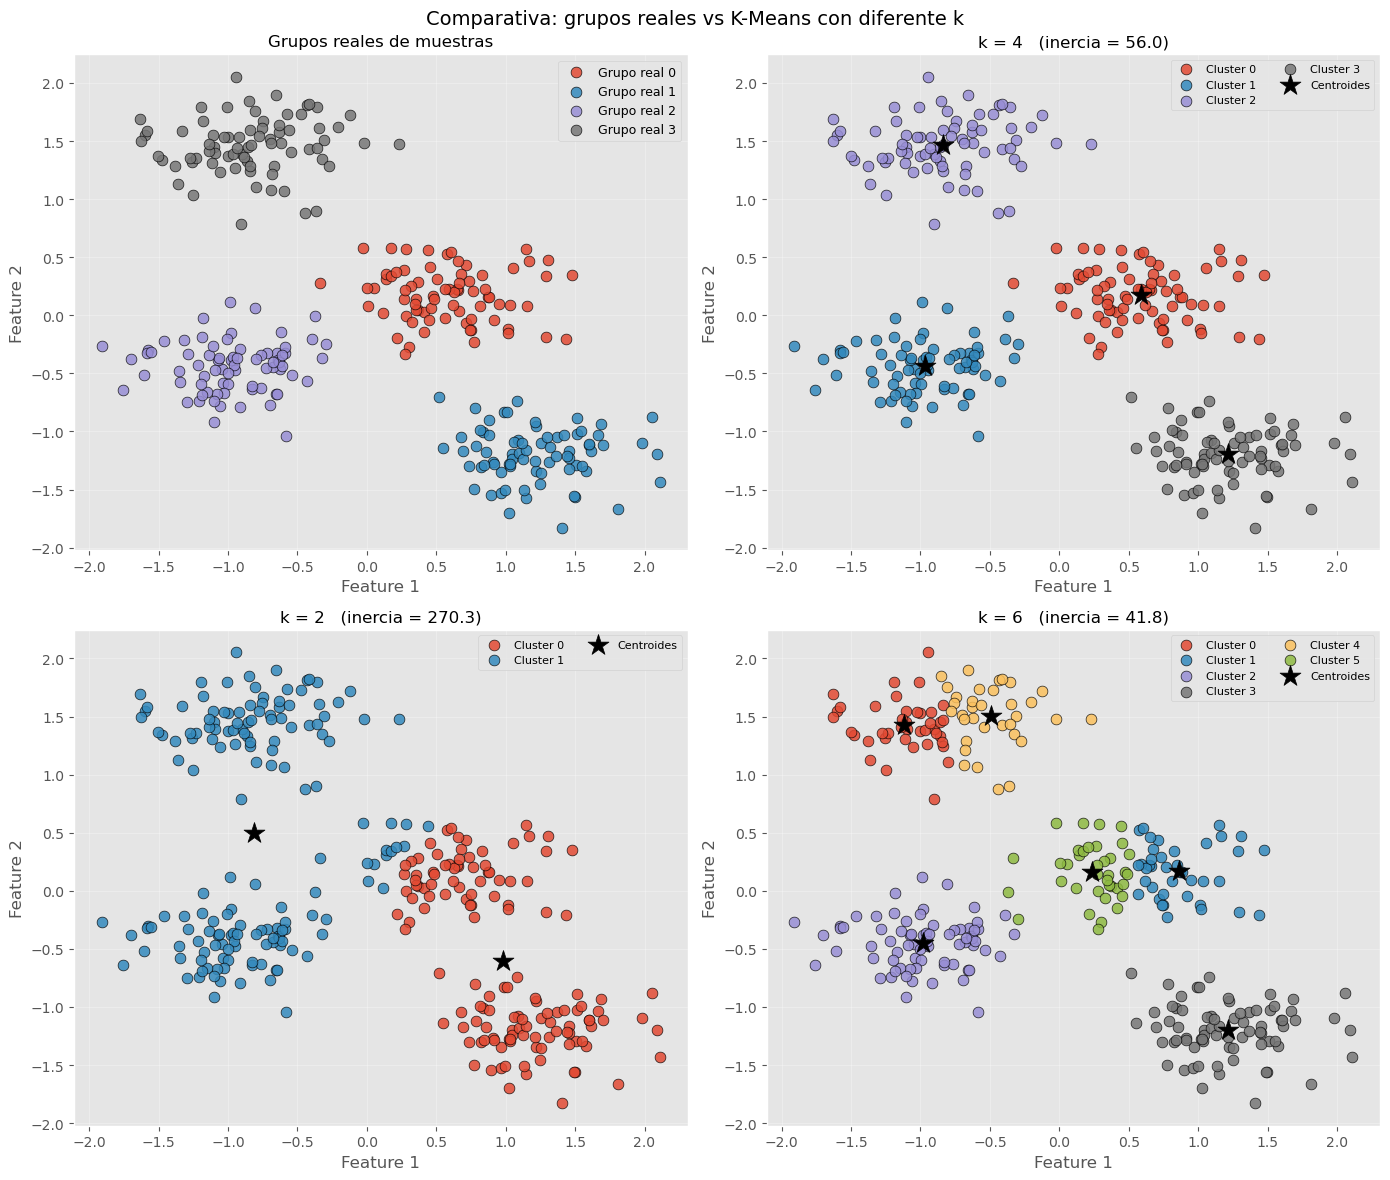


💡 Interpretación:
   k=2 → dos grupos fusionan pares de clusters reales
   k=4 → coincide con los grupos reales (matriz diagonal)
   k=6 → algunos grupos reales se parten en dos sub-clusters


In [7]:
# Visualización comparativa: grupos reales + k=2, k=4, k=6
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Comparativa: grupos reales vs K-Means con diferente k', fontsize=14)

# Panel [0,0]: grupos reales
for i in np.unique(y3):
    ax[0, 0].scatter(
        x=X3_scaled[y3 == i, 0],
        y=X3_scaled[y3 == i, 1],
        c=colors[i], marker='o', edgecolor='black',
        s=60, alpha=0.85, label=f'Grupo real {i}'
    )
ax[0, 0].set_title('Grupos reales de muestras', fontsize=12)
ax[0, 0].legend(fontsize=9)
ax[0, 0].grid(True, alpha=0.3)

# Paneles k=4, k=2, k=6
posiciones = [(0, 1), (1, 0), (1, 1)]
for pos, k in zip(posiciones, [4, 2, 6]):
    m, y_pred = modelos_k[k]
    r, c = pos
    for i in np.unique(y_pred):
        ax[r, c].scatter(
            x=X3_scaled[y_pred == i, 0],
            y=X3_scaled[y_pred == i, 1],
            c=colors[i % len(colors)], marker='o', edgecolor='black',
            s=60, alpha=0.85, label=f'Cluster {i}'
        )
    ax[r, c].scatter(
        x=m.cluster_centers_[:, 0],
        y=m.cluster_centers_[:, 1],
        c='black', s=250, marker='*', zorder=5, label='Centroides'
    )
    ax[r, c].set_title(f'k = {k}   (inercia = {m.inertia_:.1f})', fontsize=12)
    ax[r, c].legend(fontsize=8, ncol=2)
    ax[r, c].grid(True, alpha=0.3)

for a in ax.flat:
    a.set_xlabel('Feature 1')
    a.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print()
print('💡 Interpretación:')
print('   k=2 → dos grupos fusionan pares de clusters reales')
print('   k=4 → coincide con los grupos reales (matriz diagonal)')
print('   k=6 → algunos grupos reales se parten en dos sub-clusters')


## 📐 Paso 6: ¿Cuántos Clusters usar? — Método del Codo y Silhouette

En la práctica no conocemos el k verdadero. Usamos dos métricas complementarias:

- **Inercia (Elbow/Codo)**: buscamos el punto donde la ganancia de reducir la inercia se estabiliza
- **Índice de Silueta**: buscamos el k que maximiza la silueta media (mejor cohesión + separación)

Ambas curvas deben analizarse juntas: el k ideal es consistente entre las dos.


In [8]:
# Dataset para análisis de k óptimo (mismo que 04n-ClustersAnalysis.py)
X4, y4 = make_blobs(n_samples=300, n_features=2, centers=4, cluster_std=0.60,
                    shuffle=True, random_state=0)
X4_scaled = preprocessing.scale(X4)

range_n_clusters = range(2, 15)
inertias = []
valores_silhouette = []

for n_clusters in range_n_clusters:
    modelo = KMeans(n_clusters=n_clusters, n_init=20, random_state=123)
    modelo.fit(X=X4_scaled)
    cluster_labels = modelo.predict(X=X4_scaled)
    inertias.append(modelo.inertia_)
    silhouette_avg = silhouette_score(X4_scaled, cluster_labels)
    valores_silhouette.append(silhouette_avg)

# Identificar k óptimo por silhouette
k_optimo = list(range_n_clusters)[np.argmax(valores_silhouette)]

print(f'📊 Barrido de k=2 a k=14:')
print(f"  {'k':>4} {'Inercia':>12} {'Silhouette':>12}")
print(f"  {'-'*32}")
for k, (ine, sil) in zip(range_n_clusters, zip(inertias, valores_silhouette)):
    marker = ' ◄ máximo silhouette' if k == k_optimo else ''
    print(f"  {k:>4} {ine:>12.2f} {sil:>12.4f}{marker}")


📊 Barrido de k=2 a k=14:
     k      Inercia   Silhouette
  --------------------------------
     2       270.34       0.4768
     3       139.35       0.5712
     4        56.02       0.6569 ◄ máximo silhouette
     5        48.60       0.5811
     6        41.80       0.5059
     7        35.22       0.4522
     8        29.42       0.3972
     9        27.25       0.3782
    10        25.19       0.3706
    11        23.49       0.3866
    12        21.92       0.3373
    13        19.84       0.3543
    14        18.74       0.3533


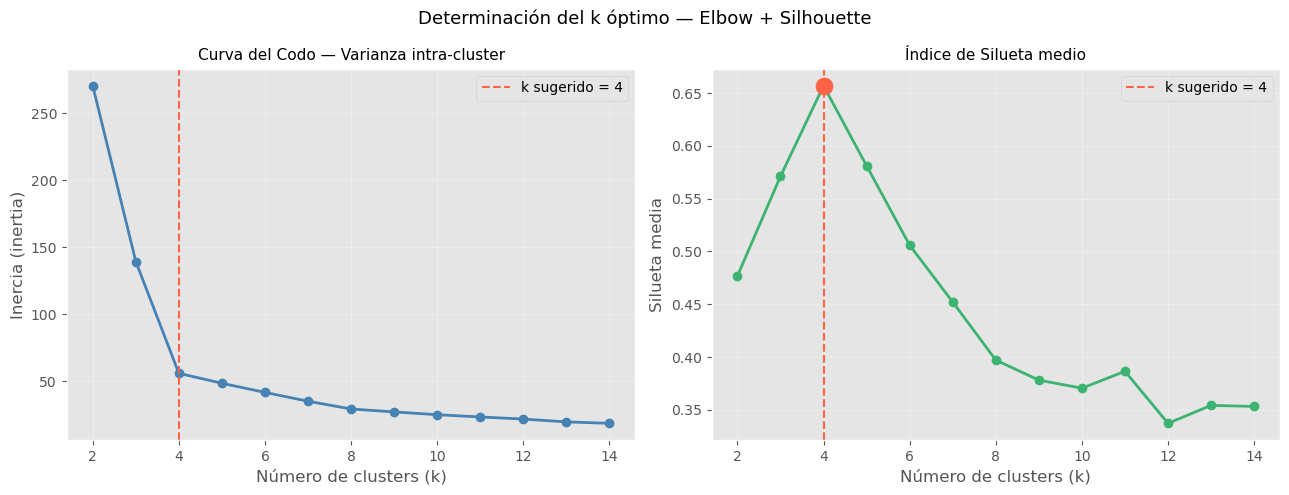

💡 Ambas curvas señalan k=4 como el número óptimo de clusters.
   Coincide con los 4 grupos reales del dataset simulado.


In [9]:
# Gráfico: Curva del Codo + Silhouette
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Determinación del k óptimo — Elbow + Silhouette', fontsize=13)

# Panel izquierdo: inercia (elbow)
ax[0].plot(range_n_clusters, inertias, marker='o', color='steelblue', linewidth=2)
ax[0].axvline(k_optimo, color='tomato', linestyle='--', linewidth=1.5,
              label=f'k sugerido = {k_optimo}')
ax[0].set_title('Curva del Codo — Varianza intra-cluster', fontsize=11)
ax[0].set_xlabel('Número de clusters (k)')
ax[0].set_ylabel('Inercia (inertia)')
ax[0].legend(fontsize=10)
ax[0].grid(True, alpha=0.3)

# Panel derecho: silhouette
ax[1].plot(range_n_clusters, valores_silhouette, marker='o', color='mediumseagreen',
           linewidth=2)
ax[1].axvline(k_optimo, color='tomato', linestyle='--', linewidth=1.5,
              label=f'k sugerido = {k_optimo}')
ax[1].scatter([k_optimo], [max(valores_silhouette)],
              color='tomato', s=150, zorder=5)
ax[1].set_title('Índice de Silueta medio', fontsize=11)
ax[1].set_xlabel('Número de clusters (k)')
ax[1].set_ylabel('Silueta media')
ax[1].legend(fontsize=10)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'💡 Ambas curvas señalan k={k_optimo} como el número óptimo de clusters.')
print(f'   Coincide con los {len(np.unique(y4))} grupos reales del dataset simulado.')


## 🎓 Resumen y Conclusiones

### Mini resumen tipo clase

| Concepto | Clave |
|---|---|
| **¿Para qué?** | Agrupar datos **sin etiquetas** encontrando estructura interna |
| **K-Means** | Asigna cada punto al centroide más cercano (distancia Euclidea) |
| **Inercia** | Varianza intra-cluster — K-Means la minimiza |
| **¿Cuántos k?** | Elbow (codo de inercia) + Silhouette (maximizar cohesión/separación) |
| **Paso obligatorio** | Escalar con `preprocessing.scale()` antes de K-Means |
| **Validar resultado** | `crosstab(y_real, y_predict)` si hay ground truth disponible |

### ⚠️ Errores comunes

| Error | Problema | Solución |
|---|---|---|
| ❌ No escalar | Features de mayor magnitud dominan la distancia | `preprocessing.scale(X)` antes de `KMeans.fit()` |
| ❌ Elegir k sin análisis | Resultados arbitrarios y no reproducibles | Usar Elbow + Silhouette |
| ❌ Un solo `n_init` | K-Means puede converger en mínimo local | `n_init=20` o más |
| ❌ Usar K-Means con clusters no esféricos | K-Means falla con formas de media luna, anillos | Usar DBSCAN o clustering espectral |
| ❌ Confundir colores de clusters con grupos reales | Los números de cluster son arbitrarios | Analizar con crosstab, no con colores |

### 🚀 ¿Qué sigue?

- 🌳 **Clustering Jerárquico (Agglomerative/Divisive)** — dendrograma, no requiere especificar k
- 🔵 **DBSCAN** — clustering por densidad, detecta outliers, maneja formas arbitrarias
- 📊 **GMM (Gaussian Mixture Models)** — clustering probabilístico con distribuciones gaussianas
- 🌐 **K-Means sobre datos reales** — junto con PCA para reducir dimensiones primero

> 📚 **Referencia:**
> - [Clustering con Python — cienciadedatos.net](https://www.cienciadedatos.net/documentos/py20-clustering-con-python.html)
> - [scikit-learn — KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
> - [scikit-learn — Clustering](https://scikit-learn.org/stable/modules/clustering.html)


---
<br>

**Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER**

Este notebook está licenciado bajo [Creative Commons BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).
Podés compartirlo y adaptarlo con atribución y bajo la misma licencia.

*Cristian Pacifico — FCAD/UNER*
